# ResNet50-FCSSAM Normal3 - Grad-CAM conv4_block6_out, FCSSAM Attention And FACT Deletion

Notebook tao hinh Grad-CAM threshold overlay voi layer conv4_block6_out, ban do attention cua FCSSAM va FACT deletion batch cho ResNet50-FCSSAM. Khong train lai model.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMAGE_SIZE = 256
BATCH_SIZE = 16
CLASS_NAMES = ["normal", "pneumonia", "effusion"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
GRADCAM_LAYER = "conv4_block6_out"
HEATMAP_THRESHOLD = 0.45
OVERLAY_ALPHA = 0.55

MODEL_CANDIDATES = [
    Path("/kaggle/input/datasets/thuanminh1310/resnet50-fcssam-1/train_resnet50_fcssam_effusion_heavy_normal3_threshold_tf_p100/models/resnet50_fcssam/best.keras"),
    Path("/kaggle/input/resnet50-fcssam-1/train_resnet50_fcssam_effusion_heavy_normal3_threshold_tf_p100/models/resnet50_fcssam/best.keras"),
]
MANIFEST_CANDIDATES = [
    Path("/kaggle/input/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests"),
    Path("/kaggle/input/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets"),
    Path("/kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests"),
    Path("/kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets"),
]
TEST_MANIFEST_NAME = "main_test_70_15_15_effusion_heavy_normal3.csv"
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])
TEST_CSV = next((d / TEST_MANIFEST_NAME for d in MANIFEST_CANDIDATES if (d / TEST_MANIFEST_NAME).exists()), MANIFEST_CANDIDATES[0] / TEST_MANIFEST_NAME)
OUTPUT_DIR = Path("/kaggle/working/report_resnet50_fcssam_gradcam_conv4_block6_attention_fact_normal3")
FIGURE_DIR = OUTPUT_DIR / "figures"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
for directory in [OUTPUT_DIR, FIGURE_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)
print("MODEL_PATH exists:", MODEL_PATH.exists(), MODEL_PATH)
print("TEST_CSV exists:", TEST_CSV.exists(), TEST_CSV)
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)
if not TEST_CSV.exists():
    raise FileNotFoundError(TEST_CSV)


2026-05-27 13:23:12.058642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779888192.253220      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779888192.311172      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779888192.776186      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779888192.776228      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779888192.776231      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
MODEL_PATH exists: True /kaggle/input/datasets/thuanminh1310/resnet50-fcssam-1/train_resnet50_fcssam_effusion_heavy_normal3_threshold_tf_p100/models/resnet50_fcssam/best.keras
TEST_CSV exists: True /kaggle/input/datasets/thuanminh1310/datasets-version3/pbl4_main_effusion_heavy_normal3_nih_datasets/manifests/main_test_70_15_15_effusion_heavy_normal3.csv


In [2]:
layers = tf.keras.layers

@tf.keras.utils.register_keras_serializable()
class ChannelMean(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class ChannelMax(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class FuzzyChannelSelection(layers.Layer):
    def __init__(self, keep_ratio=0.80, **kwargs):
        super().__init__(**kwargs)
        self.keep_ratio = keep_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.keep_channels = max(1, int(np.ceil(channels * self.keep_ratio)))
        self.alpha = self.add_weight(name="alpha", shape=(channels,), initializer=tf.keras.initializers.RandomUniform(minval=-0.05, maxval=0.05), trainable=True)
        self.richards_A = self.add_weight(name="richards_A", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_Q = self.add_weight(name="richards_Q", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_mu = self.add_weight(name="richards_mu", shape=(), initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        A = tf.nn.softplus(self.richards_A) + 1e-6
        Q = tf.nn.softplus(self.richards_Q) + 1e-6
        scores = 1.0 / (1.0 + tf.exp(A - Q * (self.alpha - self.richards_mu)))
        topk = tf.math.top_k(scores, k=self.keep_channels, sorted=True)
        selected = tf.gather(inputs, topk.indices, axis=-1)
        selected_scores = tf.reshape(topk.values, [1, 1, 1, self.keep_channels])
        return selected * selected_scores

    def get_config(self):
        config = super().get_config()
        config.update({"keep_ratio": self.keep_ratio})
        return config

model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"ChannelMean": ChannelMean, "ChannelMax": ChannelMax, "FuzzyChannelSelection": FuzzyChannelSelection}, compile=False)
model.summary()


I0000 00:00:1779888207.299934      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779888207.306033      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "resnet50_fcssam_effusion_heavy_nih"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 41,493,073 (158.28 MB)

 Trainable params: 41,431,761 (158.05 MB)

 Non-trainable params: 61,312 (239.50 KB)

In [3]:
def enhance_xray_contrast(image):
    image = tf.cast(image, tf.float32) / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)

def common_preprocess_input(image):
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean

def decode_display_and_model(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    display_rgb = tf.image.grayscale_to_rgb(image)
    model_input = common_preprocess_input(display_rgb)
    return display_rgb, model_input

test_df = pd.read_csv(TEST_CSV)
test_df = test_df.loc[test_df["class_name"].isin(CLASS_NAMES)].copy().reset_index(drop=True)
test_df["class_index"] = test_df["class_name"].map(CLASS_TO_INDEX).astype(np.int32)
test_df["resolved_path"] = test_df["resolved_path"].astype(str)
missing = ~test_df["resolved_path"].map(lambda value: Path(value).exists())
if missing.any():
    raise FileNotFoundError("Missing image inputs. Examples: " + str(test_df.loc[missing, "resolved_path"].head(5).tolist()))
paths = test_df["resolved_path"].astype(str).values
labels = test_df["class_index"].astype(np.int32).values
display(test_df["class_name"].value_counts())


class_name
normal       1909
pneumonia     409
effusion      409
Name: count, dtype: int64

In [4]:
def normalize_heatmap_np(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.maximum(values, 0.0)
    return values / (np.max(values) + 1e-8)

def normalize_heatmap(heatmap):
    heatmap = tf.where(tf.math.is_finite(heatmap), heatmap, tf.zeros_like(heatmap))
    heatmap = tf.nn.relu(heatmap)
    return heatmap / (tf.reduce_max(heatmap) + 1e-8)

def make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name=GRADCAM_LAYER):
    grad_model = tf.keras.Model(model_obj.inputs, [model_obj.get_layer(layer_name).output, model_obj.output])
    image_tensor = tf.cast(image_tensor, tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        tape.watch(conv_outputs)
        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]
        class_score = predictions[:, class_index]
    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        return np.zeros(conv_outputs.shape[1:3], dtype=np.float32)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)[0]
    return np.nan_to_num(normalize_heatmap(heatmap).numpy(), nan=0.0, posinf=0.0, neginf=0.0)

def resize_heatmap(heatmap):
    heatmap = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap = tf.image.resize(heatmap, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    return np.nan_to_num(tf.squeeze(heatmap, axis=-1).numpy(), nan=0.0, posinf=0.0, neginf=0.0)

def overlay_heatmap(display_rgb, heatmap, threshold=HEATMAP_THRESHOLD, alpha=OVERLAY_ALPHA):
    image = np.clip(display_rgb / 255.0, 0.0, 1.0)
    heatmap = np.nan_to_num(np.clip(heatmap, 0.0, 1.0), nan=0.0, posinf=0.0, neginf=0.0)
    mask = heatmap >= threshold
    colored = plt.get_cmap("jet")(heatmap)[..., :3]
    overlay = image.copy()
    overlay[mask] = np.clip((1.0 - alpha) * image[mask] + alpha * colored[mask], 0.0, 1.0)
    return overlay

def heatmap_border_score(heatmap, border=18):
    border_mask = np.zeros_like(heatmap, dtype=bool)
    border_mask[:border, :] = True; border_mask[-border:, :] = True
    border_mask[:, :border] = True; border_mask[:, -border:] = True
    hot = heatmap >= HEATMAP_THRESHOLD
    return 1.0 if int(hot.sum()) == 0 else float(np.mean(border_mask[hot]))


In [5]:
ATTENTION_LAYERS = {
    "CAM effect": "overall_fcssam_samavg_channel_mul",
    "SAMavg": "overall_fcssam_samavg_spatial_conv",
    "SAMmax": "overall_fcssam_sammax_spatial_conv",
    "FCSSAM": "overall_fcssam_select",
}
missing_attention = [name for name in ATTENTION_LAYERS.values() if name not in [layer.name for layer in model.layers]]
if missing_attention:
    raise ValueError("Missing FCSSAM layers: " + str(missing_attention))
attention_model = tf.keras.Model(model.inputs, [model.get_layer(name).output for name in ATTENTION_LAYERS.values()])

def attention_heatmaps(input_batch):
    outputs = attention_model(input_batch, training=False)
    maps = {}
    for display_name, output in zip(ATTENTION_LAYERS.keys(), outputs):
        arr = output[0].numpy()
        if arr.ndim == 3 and arr.shape[-1] > 1:
            arr = np.mean(np.abs(arr), axis=-1)
        elif arr.ndim == 3:
            arr = arr[..., 0]
        maps[display_name] = resize_heatmap(normalize_heatmap_np(arr))
    return maps


I0000 00:00:1779888235.128505      70 service.cc:152] XLA service 0x7f6670013a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779888235.128543      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779888235.128547      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779888236.065692      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779888242.510972      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


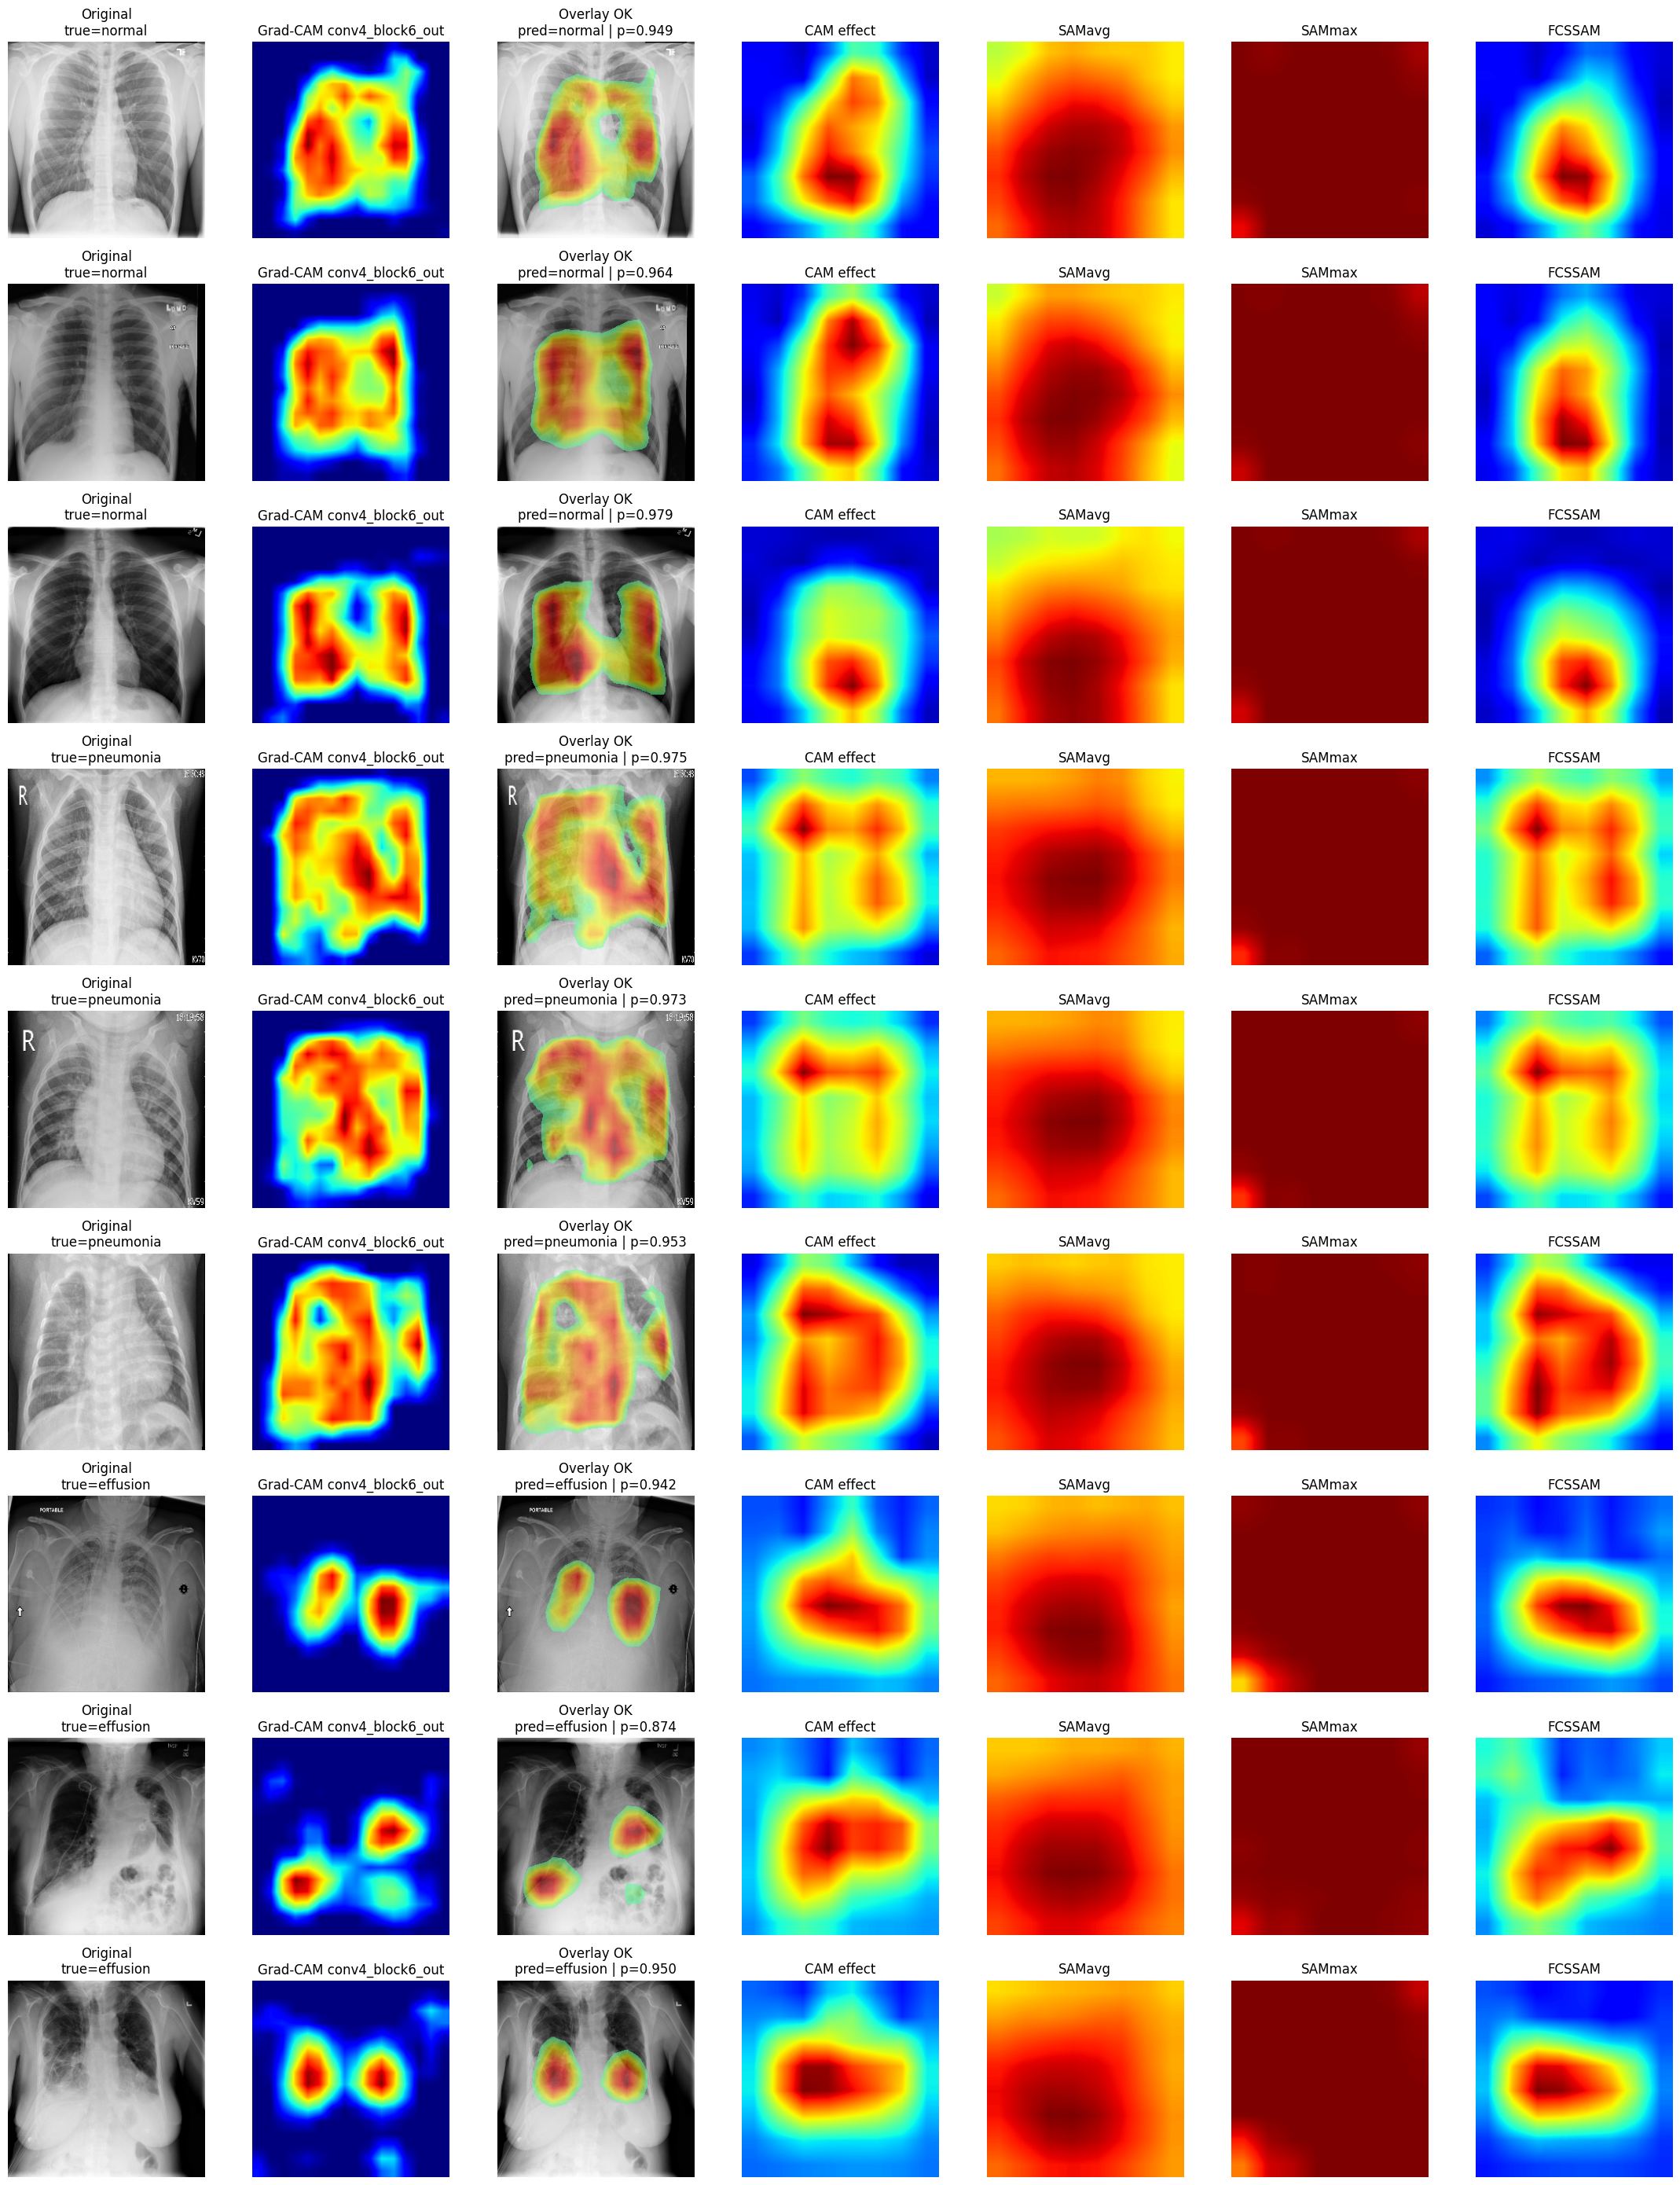

,true,pred,status,pred_prob,row
0,normal,normal,OK,0.949295,1035
1,normal,normal,OK,0.963938,550
2,normal,normal,OK,0.979062,983
3,pneumonia,pneumonia,OK,0.975346,112
4,pneumonia,pneumonia,OK,0.972732,987
5,pneumonia,pneumonia,OK,0.953119,246
6,effusion,effusion,OK,0.941513,334
7,effusion,effusion,OK,0.873959,381
8,effusion,effusion,OK,0.949908,825


pred,effusion,normal,pneumonia
true,,,
effusion,3,0,0
normal,0,3,0
pneumonia,0,0,3


saved: /kaggle/working/report_resnet50_fcssam_gradcam_conv4_block6_attention_fact_normal3/figures/resnet50_fcssam_normal3_gradcam_attention_examples.png


In [6]:
def collect_examples(per_class=3, scan_limit=1200):
    candidates_by_class = {idx: [] for idx in range(len(CLASS_NAMES))}
    for idx, (path, label) in enumerate(zip(paths[:scan_limit], labels[:scan_limit])):
        display_rgb, model_input = decode_display_and_model(path)
        display_np = display_rgb.numpy().astype(np.float32)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        pred_index = int(np.argmax(probs))
        is_correct = pred_index == int(label)
        heatmap = resize_heatmap(make_gradcam_heatmap(model, input_batch, pred_index))
        if int(np.sum(heatmap >= HEATMAP_THRESHOLD)) < 20:
            continue
        candidates_by_class[int(label)].append({"idx": idx, "path": path, "label": int(label), "pred_index": pred_index, "is_correct": is_correct, "probs": probs, "display_np": display_np, "model_input": model_input.numpy(), "heatmap": heatmap, "border_score": heatmap_border_score(heatmap), "central_score": float(np.mean(heatmap[40:216, 28:228]))})
    selected = []
    for class_idx in range(len(CLASS_NAMES)):
        class_candidates = sorted(candidates_by_class[class_idx], key=lambda x: (not x["is_correct"], x["border_score"], -x["central_score"], -float(x["probs"][x["pred_index"]])))
        if len(class_candidates) < per_class:
            print(f"Warning: only found {len(class_candidates)} {CLASS_NAMES[class_idx]} examples.")
        selected.extend(class_candidates[:per_class])
    if not selected:
        raise ValueError("No examples found.")
    return sorted(selected, key=lambda x: (x["label"], not x["is_correct"], x["border_score"], -x["central_score"]))

examples = collect_examples(per_class=3, scan_limit=1200)
fig, axes = plt.subplots(len(examples), 7, figsize=(22, 3.1 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)
records = []
for row, item in enumerate(examples):
    probs = item["probs"]
    label = item["label"]
    pred = item["pred_index"]
    input_batch = item["model_input"][None, ...]
    attn_maps = attention_heatmaps(input_batch)
    overlay = overlay_heatmap(item["display_np"], item["heatmap"])
    status = "OK" if item["is_correct"] else "WRONG"
    original_title = f"Original\ntrue={CLASS_NAMES[label]}"
    overlay_title = f"Overlay {status}\npred={CLASS_NAMES[pred]} | p={probs[pred]:.3f}"
    panels = [(original_title, item["display_np"].astype(np.uint8), None), (f"Grad-CAM {GRADCAM_LAYER}", item["heatmap"], "jet"), (overlay_title, overlay, None)]
    panels.extend([(name, heat, "jet") for name, heat in attn_maps.items()])
    for col, (title, image, cmap) in enumerate(panels):
        axes[row, col].imshow(image, cmap=cmap, vmin=0 if cmap else None, vmax=1 if cmap else None)
        axes[row, col].set_title(title)
        axes[row, col].axis("off")
    records.append({"row": int(item["idx"]), "path": item["path"], "true": CLASS_NAMES[label], "pred": CLASS_NAMES[pred], "status": status, "pred_prob": float(probs[pred]), "border_score": float(item["border_score"]), "central_score": float(item["central_score"])})
plt.tight_layout()
fig_path = FIGURE_DIR / "resnet50_fcssam_normal3_gradcam_attention_examples.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
records_df = pd.DataFrame(records)
display(records_df[["true", "pred", "status", "pred_prob", "row"]])
display(pd.crosstab(records_df["true"], records_df["pred"], rownames=["true"], colnames=["pred"], dropna=False))
records_df.to_csv(ARTIFACT_DIR / "resnet50_fcssam_normal3_gradcam_attention_examples.csv", index=False)
print("saved:", fig_path)


,fraction_deleted,mean_target_prob,mean_prob_drop,deletion_auc
0,0.0,0.888773,8.987263e-07,0.42041
1,0.1,0.607449,2.813255e-01,0.42041
2,0.2,0.506614,3.821602e-01,0.42041
3,0.3,0.458529,4.302450e-01,0.42041
4,0.4,0.418908,4.698665e-01,0.42041
5,0.5,0.392027,4.967470e-01,0.42041
6,0.6,0.391096,4.976779e-01,0.42041
7,0.7,0.394371,4.944037e-01,0.42041
8,0.8,0.394592,4.941825e-01,0.42041
9,0.9,0.392246,4.965281e-01,0.42041


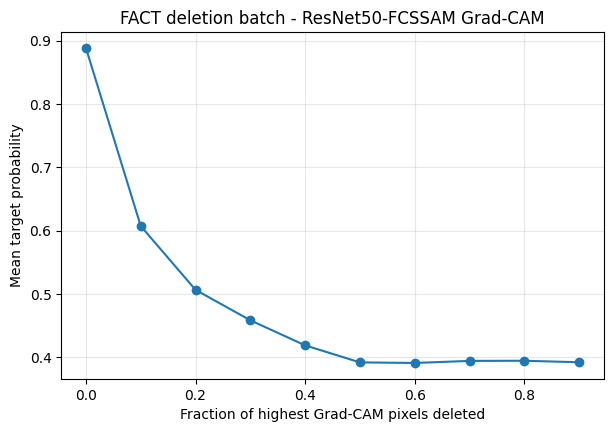

saved: /kaggle/working/report_resnet50_fcssam_gradcam_conv4_block6_attention_fact_normal3/figures/resnet50_fcssam_normal3_gradcam_fact_deletion_batch.png


In [7]:
def delete_by_heatmap_batch(model_inputs, heatmaps, fractions):
    model_inputs = np.asarray(model_inputs, dtype=np.float32)
    heatmaps = np.asarray(heatmaps, dtype=np.float32)
    baseline = np.zeros_like(model_inputs, dtype=np.float32)
    flat = heatmaps.reshape((heatmaps.shape[0], -1))
    order = np.argsort(-flat, axis=1)
    deleted_batches = []
    for fraction in fractions:
        deleted = model_inputs.copy()
        k = int(round(fraction * flat.shape[1]))
        if k > 0:
            for i in range(model_inputs.shape[0]):
                mask_flat = np.zeros(flat.shape[1], dtype=bool)
                mask_flat[order[i, :k]] = True
                mask = mask_flat.reshape((IMAGE_SIZE, IMAGE_SIZE))
                deleted[i, mask, :] = baseline[i, mask, :]
        deleted_batches.append(deleted)
    return deleted_batches

def fact_deletion_batch(max_images=64, fractions=None):
    if fractions is None:
        fractions = np.linspace(0.0, 0.9, 10)
    n = min(max_images, len(paths))
    model_inputs, target_indices, base_probs, heatmaps = [], [], [], []
    for path in paths[:n]:
        _, model_input = decode_display_and_model(path)
        input_batch = model_input[None, ...]
        probs = model.predict(input_batch, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = probs[0]
        target = int(np.argmax(probs))
        heatmaps.append(resize_heatmap(make_gradcam_heatmap(model, input_batch, target)))
        model_inputs.append(model_input.numpy())
        target_indices.append(target)
        base_probs.append(float(probs[target]))
    model_inputs = np.stack(model_inputs).astype(np.float32)
    heatmaps = np.stack(heatmaps).astype(np.float32)
    target_indices = np.asarray(target_indices, dtype=np.int32)
    base_probs = np.asarray(base_probs, dtype=np.float32)
    rows = []
    for fraction, deleted in zip(fractions, delete_by_heatmap_batch(model_inputs, heatmaps, fractions)):
        probs = model.predict(deleted, batch_size=BATCH_SIZE, verbose=0)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        target_probs = probs[np.arange(n), target_indices]
        rows.append({"fraction_deleted": float(fraction), "mean_target_prob": float(np.mean(target_probs)), "mean_prob_drop": float(np.mean(base_probs - target_probs))})
    result = pd.DataFrame(rows)
    x = result["fraction_deleted"].to_numpy(dtype=np.float32)
    y = result["mean_target_prob"].to_numpy(dtype=np.float32)
    result["deletion_auc"] = float(np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0))
    return result

deletion_df = fact_deletion_batch()
deletion_df.to_csv(ARTIFACT_DIR / "resnet50_fcssam_normal3_gradcam_fact_deletion_batch.csv", index=False)
display(deletion_df)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(deletion_df["fraction_deleted"], deletion_df["mean_target_prob"], marker="o")
ax.set_xlabel("Fraction of highest Grad-CAM pixels deleted")
ax.set_ylabel("Mean target probability")
ax.set_title("FACT deletion batch - ResNet50-FCSSAM Grad-CAM")
ax.grid(True, alpha=0.3)
plot_path = FIGURE_DIR / "resnet50_fcssam_normal3_gradcam_fact_deletion_batch.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved:", plot_path)
